*Sergey Tomin (sergey.tomin@desy.de). June 2026.*

---
sidebar_position: 18
title: 18. Runge-Kutta Tracking
description: Runge-Kutta beam tracking and arbitrary magnetic fields in OCELOT
---

# Runge-Kutta Tracking

OCELOT has used Runge-Kutta tracking for trajectory calculations in magnetic fields for a long time. This is needed, for example, by synchrotron-radiation and CSR calculations, where the trajectory in a complex magnet has to be known in a fixed Cartesian frame.

The same field integrator can also be used as a beam-tracking transfer map. There are two RK maps:

- `RungeKuttaGlobalTM` integrates in the fixed Cartesian field frame. The old name `RungeKuttaTM` is kept as an alias for this behavior.
- `RungeKuttaOcelotTM` integrates in the same field, but returns OCELOT coordinates relative to the transported reference particle.

For many normal lattice calculations `SecondTM` or kick maps are still faster and should be used first. RK tracking is useful when the magnetic field itself is the object of the model: arbitrary field regions, soft edges, offset magnets used as combined-function magnets, or checks against trajectory-style calculations.

The older compact examples are still useful references:

- [tracking the electron beam with Runge-Kutta integrator in magnetic fields](https://www.ocelot-collab.com/docs/tutorial/tutorial-beam-dynamics/small_useful_features/#tracking-the-electron-beam-with-runge-kutta-integrator-in-magnetic-fields)
- [demos/ebeam/rk_track.py](https://github.com/ocelot-collab/ocelot/blob/dev/demos/ebeam/rk_track.py)

## Imports

In [3]:
%matplotlib inline
import sys 
sys.path.append("../..")
from copy import copy, deepcopy

import numpy as np
import matplotlib.pyplot as plt

from ocelot import *
from ocelot.cpbd.track import lattice_track, track, tracking_step
from ocelot.cpbd.high_order import rk_track_in_field
from ocelot.cpbd.transformations.runge_kutta import RungeKuttaGlobalTM, RungeKuttaOcelotTM, RungeKuttaTM

plt.rcParams.update({"figure.figsize": (8.0, 4.6), "axes.grid": True})
energy = 1.0  # GeV

initializing ocelot...


## Example 1: standard lattice, three transfer-map choices

First use only standard OCELOT elements: drifts, two quadrupoles, and one small dipole. The particle is tracked with `lattice_track()`, so every point in the plot is an element exit. This is not a dense trajectory inside elements; it is just the cleanest way to compare the coordinate convention of the three transfer maps.

`SecondTM` and `RungeKuttaOcelotTM` return OCELOT coordinates relative to the reference trajectory. `RungeKuttaGlobalTM` returns fixed-frame coordinates. The difference appears at the dipole, because the dipole field bends even the zero particle in the fixed frame.

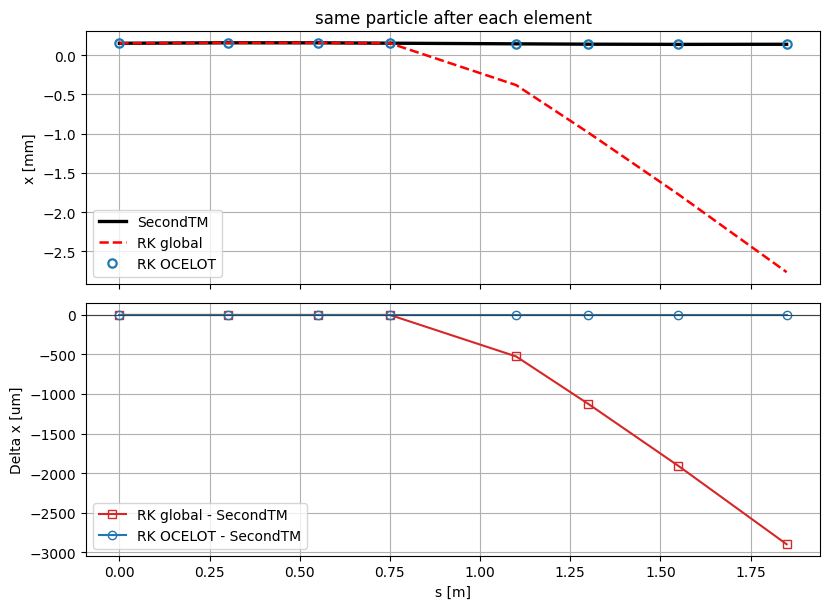

SecondTM : x_end =  0.137202 mm, px_end =  0.004212 mrad
RK global: x_end = -2.762974 mm, px_end = -3.297996 mrad
RK OCELOT: x_end =  0.137205 mm, px_end =  0.004216 mrad


In [4]:
cell = (
    Drift(l=0.30, eid="D1"),
    Quadrupole(l=0.25, k1=1.1, npoints=700, eid="QF"),
    Drift(l=0.20, eid="D2"),
    Bend(l=0.35, angle=0.003, e1=0.0, e2=0.0, npoints=900, eid="B1"),
    Drift(l=0.20, eid="D3"),
    Quadrupole(l=0.25, k1=-0.8, npoints=700, eid="QD"),
    Drift(l=0.30, eid="D4"),
)

lat_second = MagneticLattice(deepcopy(cell), method={"global": SecondTM})
lat_global = MagneticLattice(
    deepcopy(cell),
    method={"global": SecondTM, Bend: RungeKuttaGlobalTM, Quadrupole: RungeKuttaGlobalTM},
)
lat_ocelot = MagneticLattice(
    deepcopy(cell),
    method={"global": SecondTM, Bend: RungeKuttaOcelotTM, Quadrupole: RungeKuttaOcelotTM},
)

tracks = {}
for label, lat in (
    ("SecondTM", lat_second),
    ("RK global", lat_global),
    ("RK OCELOT", lat_ocelot),
):
    particle = Particle(x=150e-6, px=20e-6, E=energy)
    plist = lattice_track(lat, particle)
    tracks[label] = {
        "s": np.array([p.s for p in plist]),
        "x": np.array([p.x for p in plist]),
        "px": np.array([p.px for p in plist]),
    }

fig, axes = plt.subplots(2, 1, figsize=(8.4, 6.2), sharex=True)
axes[0].plot(tracks["SecondTM"]["s"], tracks["SecondTM"]["x"] * 1e3, "k-", lw=2.4, label="SecondTM")
axes[0].plot(tracks["RK global"]["s"], tracks["RK global"]["x"] * 1e3, "r--", lw=1.8, label="RK global")
axes[0].plot(
    tracks["RK OCELOT"]["s"],
    tracks["RK OCELOT"]["x"] * 1e3,
    "o",
    ms=6,
    mfc="none",
    mec="tab:blue",
    mew=1.6,
    label="RK OCELOT",
)
axes[0].set_ylabel("x [mm]")
axes[0].set_title("same particle after each element")
axes[0].legend()

for label, color, marker in (("RK global", "tab:red", "s"), ("RK OCELOT", "tab:blue", "o")):
    residual = (tracks[label]["x"] - tracks["SecondTM"]["x"]) * 1e6
    axes[1].plot(tracks[label]["s"], residual, marker=marker, color=color, mfc="none", label=f"{label} - SecondTM")
axes[1].axhline(0.0, color="0.25", lw=0.8)
axes[1].set_xlabel("s [m]")
axes[1].set_ylabel("Delta x [um]")
axes[1].legend()
plt.tight_layout()
plt.show()

for label in tracks:
    print(f"{label:9s}: x_end = {tracks[label]['x'][-1] * 1e3: .6f} mm, px_end = {tracks[label]['px'][-1] * 1e3: .6f} mrad")

## Example 2: arbitrary soft-edge field in a Bend

Any magnet can carry a user magnetic field through `element.mag_field`. Here the element is a `Bend`, not a `Drift`, because the physical object is still a dipole region in the lattice.

The function below is a longitudinal soft-edge vertical field. The hard-edge comparison bend uses the same integrated field, so the two models have the same nominal total angle. We track the same particle with `tracking_step()` to show the beam-dynamics difference along the element.

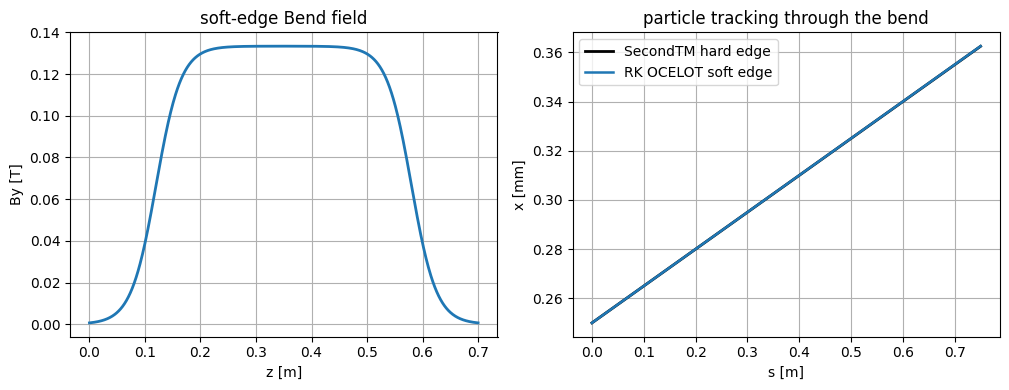

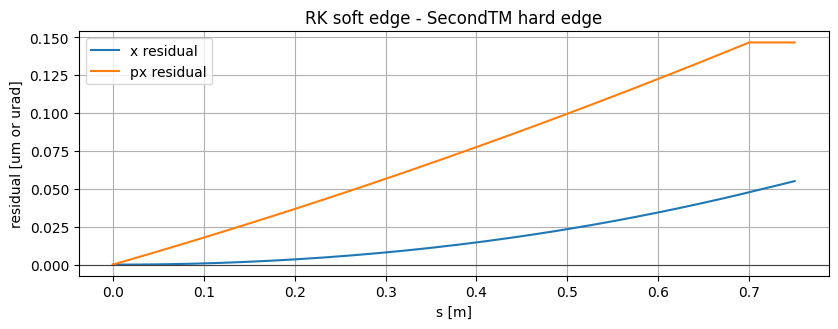

integrated soft-edge angle = 1.839132951e-02 rad
final x difference  = 0.055036 um
final px difference = 0.146451 urad


In [5]:
gamma = energy / m_e_GeV
beta_rel = np.sqrt(1.0 - 1.0 / gamma**2)
brho = beta_rel * energy * 1e9 / speed_of_light

soft_length = 0.70
z1 = 0.12
z2 = 0.58
edge_width = 0.045
peak_curvature = 0.040
peak_by = brho * peak_curvature


def soft_profile(z):
    return 0.5 * (np.tanh((z - z1) / edge_width) - np.tanh((z - z2) / edge_width))


def soft_bend_field(x, y, z):
    by = peak_by * soft_profile(z)
    return 0.0 * x, by + 0.0 * x, 0.0 * x


z_grid = np.linspace(0.0, soft_length, 800)
by_grid = peak_by * soft_profile(z_grid)
soft_angle = np.trapezoid(by_grid, z_grid) / brho

soft_bend = Bend(l=soft_length, angle=soft_angle, e1=0.0, e2=0.0, npoints=80, eid="B_SOFT")
soft_bend.mag_field = soft_bend_field
hard_bend = Bend(l=soft_length, angle=soft_angle, e1=0.0, e2=0.0, eid="B_HARD")

lat_soft = MagneticLattice((soft_bend, Drift(l=0.05, eid="D_AFTER")), method={Bend: RungeKuttaOcelotTM})
lat_hard = MagneticLattice((hard_bend, Drift(l=0.05, eid="D_AFTER")), method={Bend: SecondTM})

p_soft = Particle(x=0.25e-3, px=0.15e-3, E=energy)
p_hard = Particle(x=0.25e-3, px=0.15e-3, E=energy)
navi_soft = Navigator(lat_soft)
navi_hard = Navigator(lat_hard)

s_soft = [p_soft.s]
x_soft = [p_soft.x]
px_soft = [p_soft.px]
s_hard = [p_hard.s]
x_hard = [p_hard.x]
px_hard = [p_hard.px]

dz = soft_length / 120
while navi_soft.z0 < lat_soft.totalLen - 1e-12:
    step = min(dz, lat_soft.totalLen - navi_soft.z0)
    tracking_step(lat_soft, [p_soft], dz=step, navi=navi_soft)
    tracking_step(lat_hard, [p_hard], dz=step, navi=navi_hard)
    s_soft.append(p_soft.s)
    x_soft.append(p_soft.x)
    px_soft.append(p_soft.px)
    s_hard.append(p_hard.s)
    x_hard.append(p_hard.x)
    px_hard.append(p_hard.px)

s_soft = np.array(s_soft)
x_soft = np.array(x_soft)
px_soft = np.array(px_soft)
s_hard = np.array(s_hard)
x_hard = np.array(x_hard)
px_hard = np.array(px_hard)

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.0))
axes[0].plot(z_grid, by_grid, lw=2.0)
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("By [T]")
axes[0].set_title("soft-edge Bend field")

axes[1].plot(s_hard, x_hard * 1e3, "k-", lw=2.0, label="SecondTM hard edge")
axes[1].plot(s_soft, x_soft * 1e3, "tab:blue", lw=1.8, label="RK OCELOT soft edge")
axes[1].set_xlabel("s [m]")
axes[1].set_ylabel("x [mm]")
axes[1].set_title("particle tracking through the bend")
axes[1].legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.4, 3.4))
plt.plot(s_soft, (x_soft - x_hard) * 1e6, color="tab:blue", label="x residual")
plt.plot(s_soft, (px_soft - px_hard) * 1e6, color="tab:orange", label="px residual")
plt.axhline(0.0, color="0.25", lw=0.8)
plt.xlabel("s [m]")
plt.ylabel("residual [um or urad]")
plt.title("RK soft edge - SecondTM hard edge")
plt.legend()
plt.tight_layout()
plt.show()

print(f"integrated soft-edge angle = {soft_angle:.9e} rad")
print(f"final x difference  = {(x_soft[-1] - x_hard[-1]) * 1e6:.6f} um")
print(f"final px difference = {(px_soft[-1] - px_hard[-1]) * 1e6:.6f} urad")

## Example 3: offset quadrupole as a combined-function magnet

An offset quadrupole has a dipole component on the original design axis. `RungeKuttaOcelotTM` tracks the zero particle through the actual offset field and then uses that transported particle as the local reference. In this interpretation the offset quadrupole is a combined-function magnet.

For comparison with a conventional `Bend`, first track the zero particle through the offset quadrupole with `RungeKuttaGlobalTM`. The equivalent bend angle must come from the reference-particle exit slope. With the sign convention in this example:

```python
angle = -atan(px_ref)
```

The simple beam line below is tracked three times with `track(...)`:

- centered quadrupole, `SecondTM`
- offset quadrupole, `RungeKuttaOcelotTM`
- equivalent `Bend(angle=-atan(px_ref), k1=q.k1)`, `SecondTM`

[INFO    ] Using Twiss parameters — overriding sigma_{x,px,y,py} values.


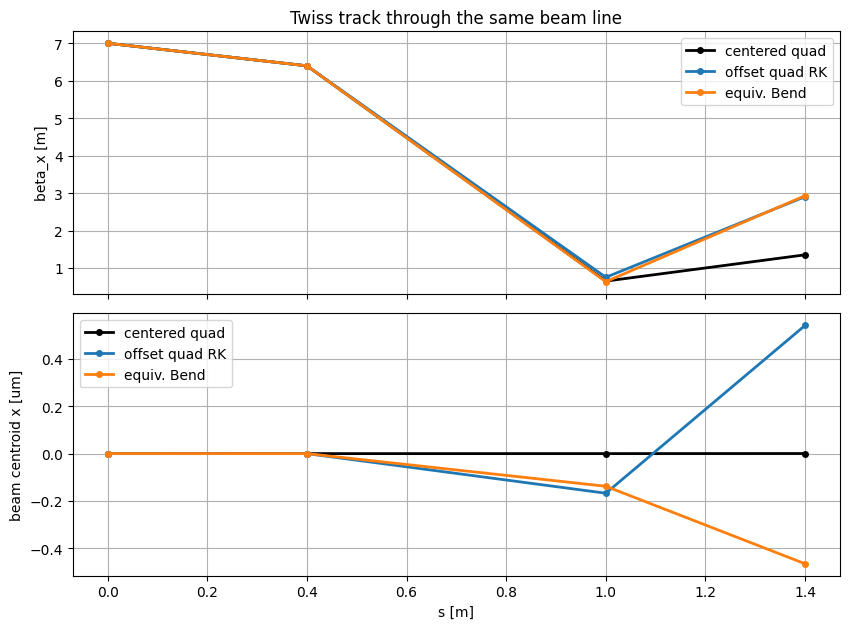

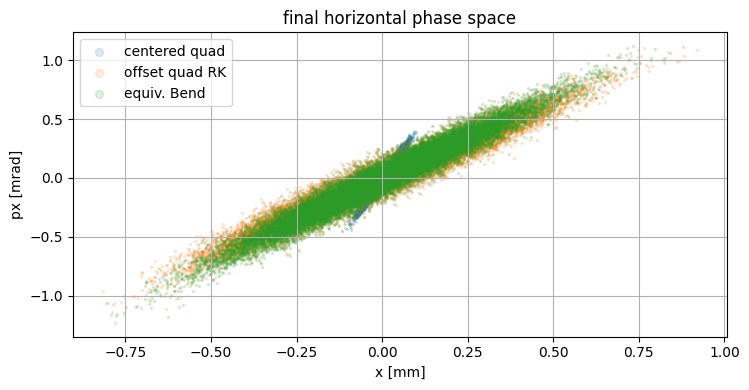

offset dx = 20.0 mm
reference exit x  = 12.757669 mm
reference exit px = 37.304761 mrad
equivalent Bend angle = -3.728747041e-02 rad
final beta_x, offset quad RK = 2.904724 m
final beta_x, equivalent Bend = 2.930574 m
final beta_x, centered quad   = 1.351287 m


In [6]:
quad_length = 0.60
quad_k1 = 4.0
quad_dx = 0.020

q_reference = Quadrupole(l=quad_length, k1=quad_k1, dx=quad_dx, npoints=4000, eid="Q_REF")
q_reference.set_tm(RungeKuttaGlobalTM)
reference = Particle(E=energy)
for tm in q_reference.tms:
    tm.apply(reference)

equivalent_angle = -np.arctan(reference.px)

d1 = Drift(l=0.40, eid="D1")
d2 = Drift(l=0.40, eid="D2")

lat_centered = MagneticLattice(
    (deepcopy(d1), Quadrupole(l=quad_length, k1=quad_k1, eid="Q_CENTER"), deepcopy(d2)),
    method={"global": SecondTM},
)
q_offset = Quadrupole(l=quad_length, k1=quad_k1, dx=quad_dx, npoints=2500, eid="Q_OFFSET")
lat_offset = MagneticLattice(
    (deepcopy(d1), q_offset, deepcopy(d2)),
    method={"global": SecondTM},
)
q_offset.set_tm(RungeKuttaOcelotTM)
lat_bend = MagneticLattice(
    (
        deepcopy(d1),
        Bend(l=quad_length, angle=equivalent_angle, k1=quad_k1, e1=0.0, e2=0.0, eid="B_EQ"),
        deepcopy(d2),
    ),
    method={"global": SecondTM},
)

np.random.seed(5)
tws0 = Twiss(beta_x=7.0, alpha_x=0.8, beta_y=6.0, alpha_y=-0.3, emit_xn=1.0e-6, emit_yn=1.0e-6, E=energy)
beam0 = generate_parray(tws=tws0, nparticles=25000, energy=energy, sigma_tau=1.0e-6, sigma_p=0.0, charge=250e-12)

tws_centered, beam_centered = track(lat_centered, deepcopy(beam0), print_progress=False)
tws_offset, beam_offset = track(lat_offset, deepcopy(beam0), print_progress=False)
tws_bend, beam_bend = track(lat_bend, deepcopy(beam0), print_progress=False)

fig, axes = plt.subplots(2, 1, figsize=(8.6, 6.4), sharex=True)
for label, tws_track, style in (
    ("centered quad", tws_centered, "k-"),
    ("offset quad RK", tws_offset, "tab:blue"),
    ("equiv. Bend", tws_bend, "tab:orange"),
):
    s = np.array([tw.s for tw in tws_track])
    beta_x = np.array([tw.beta_x for tw in tws_track])
    beta_y = np.array([tw.beta_y for tw in tws_track])
    x_centroid = np.array([tw.x for tw in tws_track])
    axes[0].plot(s, beta_x, style, lw=2.0, marker="o", ms=4, label=label)
    axes[1].plot(s, x_centroid * 1e6, style, lw=2.0, marker="o", ms=4, label=label)

axes[0].set_ylabel("beta_x [m]")
axes[0].set_title("Twiss track through the same beam line")
axes[0].legend()
axes[1].set_xlabel("s [m]")
axes[1].set_ylabel("beam centroid x [um]")
axes[1].legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7.6, 4.0))
plt.scatter(beam_centered.x() * 1e3, beam_centered.px() * 1e3, s=2, alpha=0.15, label="centered quad")
plt.scatter(beam_offset.x() * 1e3, beam_offset.px() * 1e3, s=2, alpha=0.15, label="offset quad RK")
plt.scatter(beam_bend.x() * 1e3, beam_bend.px() * 1e3, s=2, alpha=0.15, label="equiv. Bend")
plt.xlabel("x [mm]")
plt.ylabel("px [mrad]")
plt.title("final horizontal phase space")
plt.legend(markerscale=4)
plt.tight_layout()
plt.show()

print(f"offset dx = {quad_dx * 1e3:.1f} mm")
print(f"reference exit x  = {reference.x * 1e3:.6f} mm")
print(f"reference exit px = {reference.px * 1e3:.6f} mrad")
print(f"equivalent Bend angle = {equivalent_angle:.9e} rad")
print(f"final beta_x, offset quad RK = {tws_offset[-1].beta_x:.6f} m")
print(f"final beta_x, equivalent Bend = {tws_bend[-1].beta_x:.6f} m")
print(f"final beta_x, centered quad   = {tws_centered[-1].beta_x:.6f} m")

## Setting the integration step inside an element

The RK integration uses `npoints` longitudinal integration points inside the element. The default is 200.

`npoints` can be set in the element constructor and then used later when the lattice selects an RK map through `MagneticLattice(..., method={...})`. This is the simplest way to give different elements different RK grids.

In [7]:
q_step = Quadrupole(l=0.5, k1=0.7, npoints=1200, eid="Q_STEP")
lat_step = MagneticLattice((q_step,), method={Quadrupole: RungeKuttaOcelotTM})
print("npoints from constructor:", q_step.tms[0].npoints)

q_step.set_tm(RungeKuttaOcelotTM, npoints=600)
print("npoints after explicit set_tm override:", q_step.tms[0].npoints)

npoints from constructor: 1200
npoints after explicit set_tm override: 600


## Last example: using the low-level RK field integrator

Most beam tracking should use transfer maps in a `MagneticLattice`. Sometimes, however, one wants the raw trajectory inside a magnetic field, for example for diagnostics or radiation calculations. In that case the lower-level function is `rk_track_in_field(...)`.

Here the field is a constant vertical magnetic field, so the analytical solution is a circular arc. This makes it a compact check of the low-level integrator.

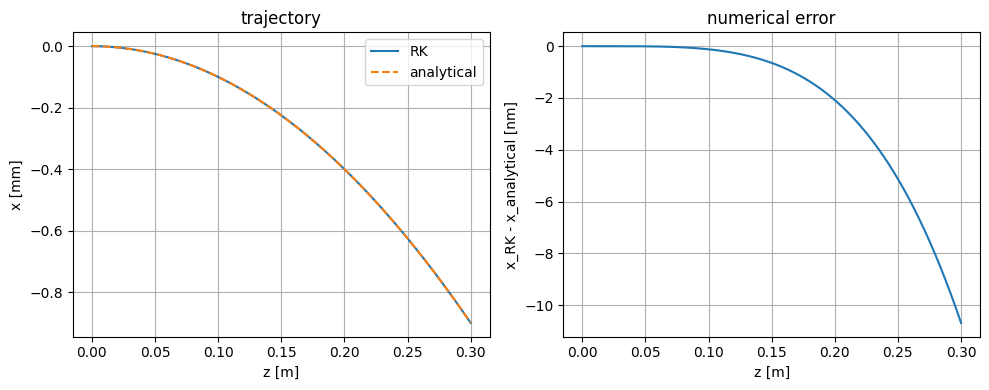

field By = 6.671281e-02 T
final RK x  = -0.900007983 mm
final ana x = -0.899997300 mm
final RK px  = -6.000107220 mrad
final ana px = -6.000072001 mrad


In [8]:
field_length = 0.30
target_angle = 6.0e-3
constant_by = brho * target_angle / field_length


def constant_vertical_field(x, y, z):
    return 0.0 * x, constant_by + 0.0 * x, 0.0 * x


zero = ParticleArray(n=1)
zero.E = energy
zero.rparticles[:] = 0.0

trajectory = rk_track_in_field(zero.rparticles.copy(), field_length, 1200, energy, constant_vertical_field)
x_rk = trajectory[0::9, 0]
px_rk = trajectory[1::9, 0]
z_rk = trajectory[4::9, 0]

rho = field_length / target_angle
x_analytical = -rho * (1.0 - np.cos(z_rk / rho))
px_analytical = -np.tan(z_rk / rho)

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0))
axes[0].plot(z_rk, x_rk * 1e3, label="RK")
axes[0].plot(z_rk, x_analytical * 1e3, "--", label="analytical")
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("x [mm]")
axes[0].set_title("trajectory")
axes[0].legend()

axes[1].plot(z_rk, (x_rk - x_analytical) * 1e9)
axes[1].set_xlabel("z [m]")
axes[1].set_ylabel("x_RK - x_analytical [nm]")
axes[1].set_title("numerical error")
plt.tight_layout()
plt.show()

print(f"field By = {constant_by:.6e} T")
print(f"final RK x  = {x_rk[-1] * 1e3:.9f} mm")
print(f"final ana x = {x_analytical[-1] * 1e3:.9f} mm")
print(f"final RK px  = {px_rk[-1] * 1e3:.9f} mrad")
print(f"final ana px = {px_analytical[-1] * 1e3:.9f} mrad")

## Summary

Use `RungeKuttaOcelotTM` when the result should remain in OCELOT coordinates. Use `RungeKuttaGlobalTM` or the legacy `RungeKuttaTM` name when the fixed-frame trajectory itself is the object of interest.

Use `MagneticLattice(..., method={...})` for normal tracking-map selection:

```python
method = {
    "global": SecondTM,
    Bend: RungeKuttaOcelotTM,
    Quadrupole: RungeKuttaOcelotTM,
}
```

Use `element.mag_field = my_field` when the element should use a user-supplied field. This works for magnets such as `Bend`, `Quadrupole`, `Sextupole`, `Octupole`, `Solenoid`, `Undulator`, and also for `Drift` field regions.

Offsets such as `dx` and `dy` are included in the default hard-edge RK fields. `RungeKuttaGlobalTM` shows the fixed-frame kick. `RungeKuttaOcelotTM` can treat the same offset as part of the transported reference trajectory, which is useful for combined-function interpretations.